In [67]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st


# Data loading, cleaning and exploring

In [68]:
students = pd.read_csv("data.csv", sep = ';')
students.head(3)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance\t,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout


In [69]:
students.shape

(4424, 37)

In [70]:
students.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance	                     4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

**Conclusion**

- We have only 'Target' column with datatype 'str'. 
- All other columns are numerical ('int' or 'float')

# Integrity check

In [71]:
students.isna().sum().sum()

np.int64(0)

In [72]:
students.duplicated().sum()

np.int64(0)

In [73]:
students.nunique()

Marital status                                      6
Application mode                                   18
Application order                                   8
Course                                             17
Daytime/evening attendance\t                        2
Previous qualification                             17
Previous qualification (grade)                    101
Nacionality                                        21
Mother's qualification                             29
Father's qualification                             34
Mother's occupation                                32
Father's occupation                                46
Admission grade                                   620
Displaced                                           2
Educational special needs                           2
Debtor                                              2
Tuition fees up to date                             2
Gender                                              2
Scholarship holder          

In [74]:
students.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime/evening attendance\t,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous qualification (grade),4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mother's qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Father's qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


**Conclusion**

No missing values and no duplicates

# Data ceaning

We need only clean column names by replacing "spaces" by "_"

In [75]:
students.columns = [(column.lower()).strip().replace(" ","_") for column in students.columns]


# Exploratory Data Analysis

In [76]:
students.nunique()


marital_status                                      6
application_mode                                   18
application_order                                   8
course                                             17
daytime/evening_attendance                          2
previous_qualification                             17
previous_qualification_(grade)                    101
nacionality                                        21
mother's_qualification                             29
father's_qualification                             34
mother's_occupation                                32
father's_occupation                                46
admission_grade                                   620
displaced                                           2
educational_special_needs                           2
debtor                                              2
tuition_fees_up_to_date                             2
gender                                              2
scholarship_holder          

**Conclusion**

To identify valuable feratures for our model we need analyse correlation between **"Target"** column and group of columns: 
 - curricular_units_1st_sem_(approved) - Number of curricular units approved in the 1st semester
 - curricular_units_1st_sem_(grade) - Grade average in the 1st semester (between 0 and 20)
 - curricular_units_1st_sem_(without_evaluations)
 - curricular_units_2nd_sem_(credited) - Number of curricular units without evalutions in the 1st semester           
 - curricular_units_2nd_sem_(enrolled) - Number of curricular units credited in the 2nd semester          
 - curricular_units_2nd_sem_(evaluations)             
 - curricular_units_2nd_sem_(approved)                
 - curricular_units_2nd_sem_(grade)                  
 - curricular_units_2nd_sem_(without_evaluations)     
 - unemployment_rate                                  
 - inflation_rate                                     
 - gdp                                

**Correlation**

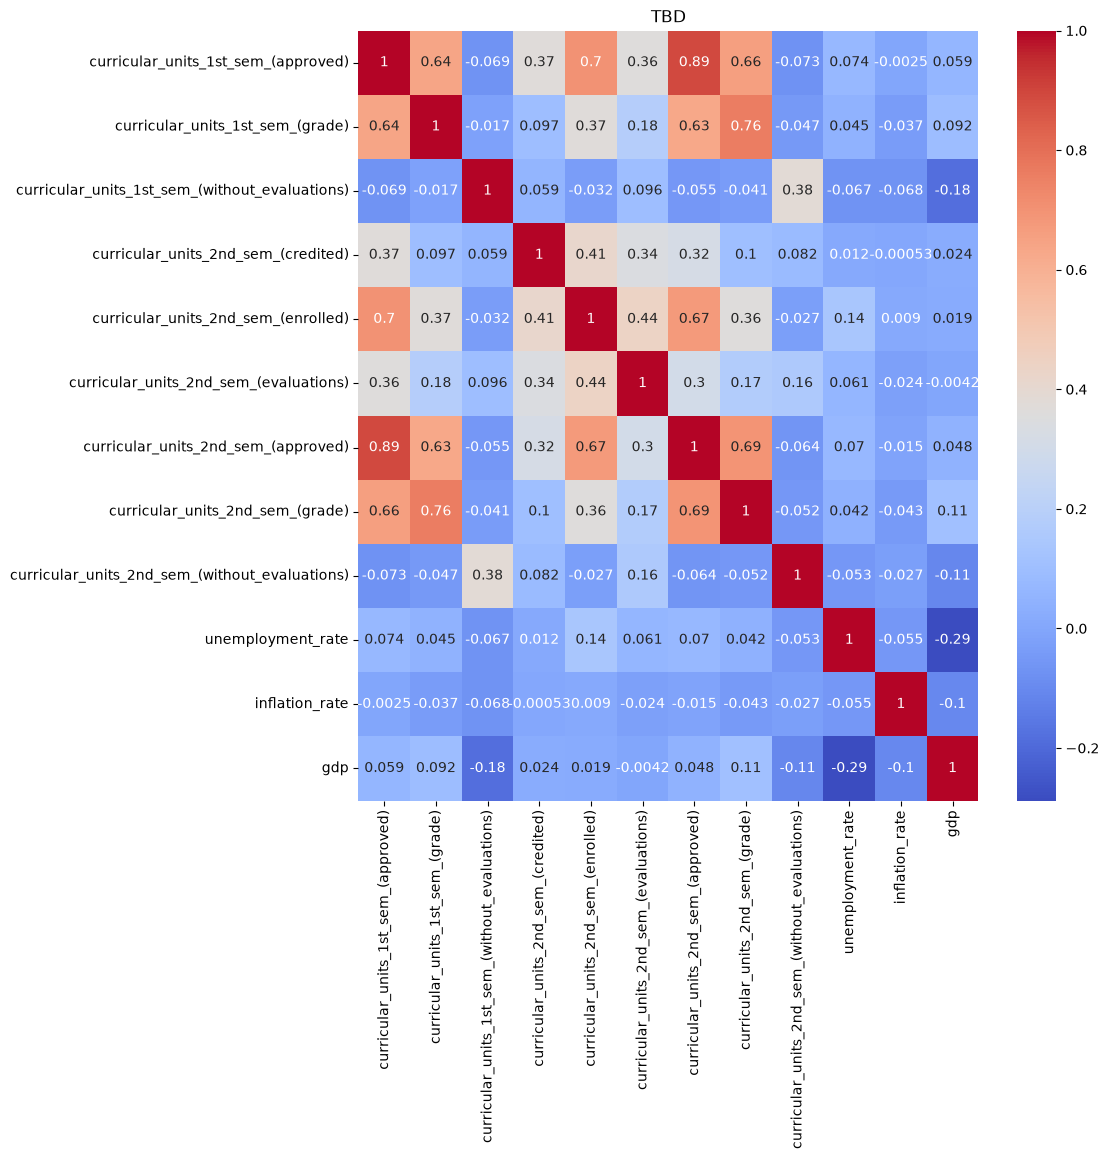

In [77]:
corr_df = students[["curricular_units_1st_sem_(approved)", "curricular_units_1st_sem_(grade)", "curricular_units_1st_sem_(without_evaluations)", "curricular_units_2nd_sem_(credited)", "curricular_units_2nd_sem_(enrolled)", "curricular_units_2nd_sem_(evaluations)", "curricular_units_2nd_sem_(approved)", "curricular_units_2nd_sem_(grade)", "curricular_units_2nd_sem_(without_evaluations)", "unemployment_rate", "inflation_rate", "gdp"]]
correlation_matrix = corr_df.corr(method='spearman')

plt.figure(figsize=(10, 10))

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm")

plt.title("TBD")
plt.show()

**Conclusion**
- we have strong correlation between "curricular_units_1st_sem_(approved)" and "curricular_units_2st_sem_(approved)" - the amount of approved units can be the same and also this amount of approved units can be valuable to split students bu category "Dropout", "Graduated", "Enrolled".
  - If we want to predict the erliest point for making decision about student, we can skip data for 2 sem
- "curricular_units_1st_sem_(approved)" and "curricular_units_1st_sem_(grade)" have also valuable correlation -> we can choose this columns for model
- inflation_rate, gdp have very week correlation with all columns. Maybe we need to use them separately 

## 1. Column "curricular_units_1st_sem_(approved)"

In [78]:
students.groupby('target')['curricular_units_1st_sem_(approved)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,2.551724,2.0,2.857588,0,21,1421
Enrolled,4.318640,5.0,2.289398,0,15,794
Graduate,6.232232,6.0,2.583380,0,26,2209


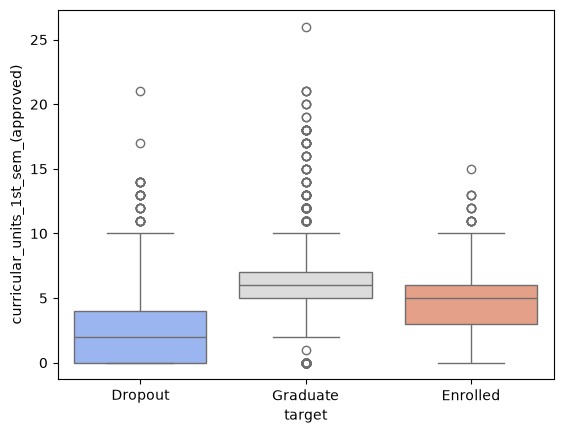

In [79]:
sns.boxplot(data=students, x='target', y='curricular_units_1st_sem_(approved)', palette="coolwarm", hue='target', legend=False);

In [80]:
def tukeys_test_outliers(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    # Define wiskers for the outliers
    lower_wisker = Q1 - 1.5 * IQR
    upper_wisker = Q3 + 1.5 * IQR

    # Identify the outliers
    outliers = data[(data < lower_wisker) | (data > upper_wisker)]

    return outliers

In [81]:
outl_dropped = tukeys_test_outliers(students[students["target"] == "Dropout"]['curricular_units_1st_sem_(approved)'])
outl_enrolled = tukeys_test_outliers(students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(approved)'])
outl_graduate = tukeys_test_outliers(students[students["target"] == "Graduate"]['curricular_units_1st_sem_(approved)'])


In [82]:
Q3_d = students[students["target"] == "Dropout"]['curricular_units_1st_sem_(approved)'].quantile(0.75)
Q1_d = students[students["target"] == "Dropout"]['curricular_units_1st_sem_(approved)'].quantile(0.25)
IQR_d = Q3_d - Q1_d

Q3_e = students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(approved)'].quantile(0.75)
Q1_e = students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(approved)'].quantile(0.25)
IQR_e = Q3_e - Q1_e

Q3_g = students[students["target"] == "Graduate"]['curricular_units_1st_sem_(approved)'].quantile(0.75)
Q1_g = students[students["target"] == "Graduate"]['curricular_units_1st_sem_(approved)'].quantile(0.25)
IQR_g = Q3_g - Q1_g

print(IQR_d)
print(IQR_e)
print(IQR_g)

4.0
3.0
2.0


In [83]:
lower_wisker = Q1_d - 1.5*IQR_d
upper_wisker = Q3_d + 1.5*IQR_d
list(students.columns).index('curricular_units_1st_sem_(approved)')
lower_outliers_indexes = students[students['curricular_units_1st_sem_(approved)'] <  lower_wisker].index
upper_outliers_indexes = students[students['curricular_units_1st_sem_(approved)'] >  upper_wisker].index
print(lower_outliers_indexes)
print(upper_outliers_indexes)

RangeIndex(start=0, stop=0, step=1)
Index([ 103,  180,  241,  346,  370,  387,  396,  406,  458,  461,
       ...
       4290, 4294, 4302, 4313, 4318, 4325, 4339, 4377, 4388, 4416],
      dtype='int64', length=180)


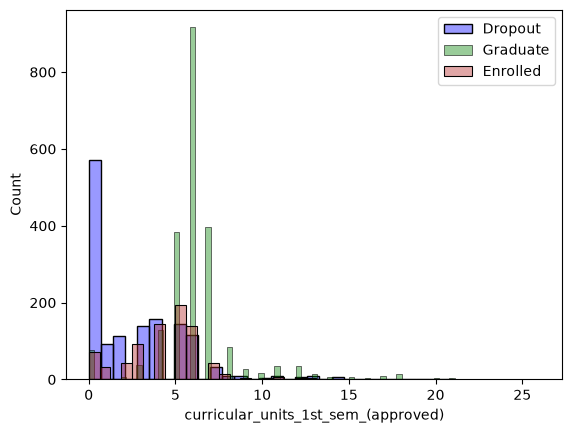

In [84]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='curricular_units_1st_sem_(approved)', color="blue", alpha=0.4, label = "Dropout", ax=axes);
sns.histplot(data=students[students['target'] == "Graduate"], x='curricular_units_1st_sem_(approved)', color="green", alpha=0.4, ax=axes, label = "Graduate", legend=True);
sns.histplot(data=students[students['target'] == "Enrolled"], x='curricular_units_1st_sem_(approved)', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled", legend=True);
axes.legend()
plt.show()

## ANOVA test

- H0 - our groups are equal
- H1 - our groups not equal

In [85]:
dropout_df = students[students["target"] == "Dropout"]['curricular_units_1st_sem_(approved)']
graduate_df = students[students["target"] == "Graduate"]['curricular_units_1st_sem_(approved)']
enrolled_df = students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(approved)']

In [86]:
st.f_oneway(dropout_df, graduate_df, enrolled_df)

F_onewayResult(statistic=np.float64(859.8667679817912), pvalue=np.float64(3.64947197e-316))

With such a small p_value, we once again, can reject the null hypothesis => This feature can be useful to categorise students by groups (Dropout, Graduate, Enrolled)

## 2. Column "curricular_units_1st_sem_(grade)"

In [87]:
students.groupby('target')['curricular_units_1st_sem_(grade)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,7.256656,10.928571,6.031120,0.0,18.000,1421
Enrolled,11.125257,12.000000,3.675084,0.0,17.000,794
Graduate,12.643655,13.000000,2.699027,0.0,18.875,2209


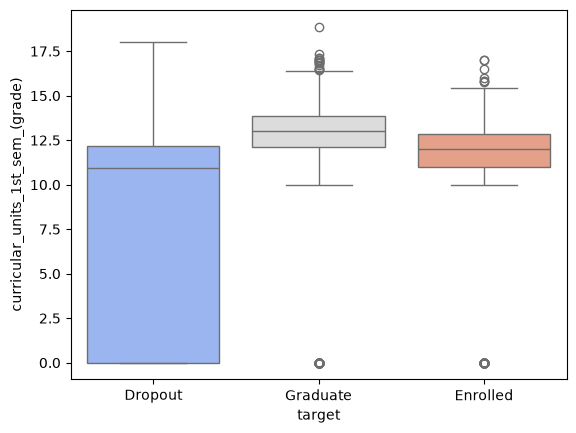

In [88]:
sns.boxplot(data=students, x='target', y='curricular_units_1st_sem_(grade)', palette="coolwarm", hue='target', legend=False);

In [89]:
outl_dropped_1 = tukeys_test_outliers(students[students["target"] == "Dropout"]['curricular_units_1st_sem_(grade)'])
outl_enrolled_1 = tukeys_test_outliers(students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(grade)'])
outl_graduate_1 = tukeys_test_outliers(students[students["target"] == "Graduate"]['curricular_units_1st_sem_(grade)'])

In [90]:
Q3_d_1 = students[students["target"] == "Dropout"]['curricular_units_1st_sem_(grade)'].quantile(0.75)
Q1_d_1 = students[students["target"] == "Dropout"]['curricular_units_1st_sem_(grade)'].quantile(0.25)
IQR_d_1 = Q3_d_1 - Q1_d_1

Q3_e_1 = students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(grade)'].quantile(0.75)
Q1_e_1 = students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(grade)'].quantile(0.25)
IQR_e_1 = Q3_e_1 - Q1_e_1

Q3_g_1 = students[students["target"] == "Graduate"]['curricular_units_1st_sem_(grade)'].quantile(0.75)
Q1_g_1 = students[students["target"] == "Graduate"]['curricular_units_1st_sem_(grade)'].quantile(0.25)
IQR_g_1 = Q3_g_1 - Q1_g_1

print(IQR_d_1)
print(IQR_e_1)
print(IQR_g_1)

12.2
1.8571428571428577
1.7357142857142875


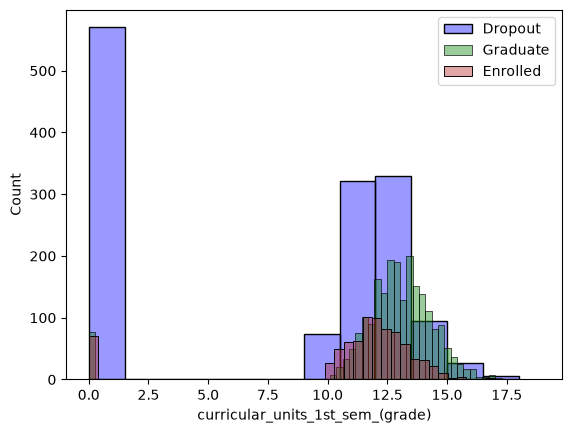

In [91]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='curricular_units_1st_sem_(grade)', color="blue", alpha=0.4, label = "Dropout", ax=axes);
sns.histplot(data=students[students['target'] == "Graduate"], x='curricular_units_1st_sem_(grade)', color="green", alpha=0.4, ax=axes, label = "Graduate", legend=True);
sns.histplot(data=students[students['target'] == "Enrolled"], x='curricular_units_1st_sem_(grade)', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled", legend=True);
axes.legend()
plt.show()

### ANOVA test
- H0 - our groups are equal
- H1 - our groups not equal

In [92]:
dropout_df_1 = students[students["target"] == "Dropout"]['curricular_units_1st_sem_(grade)']
graduate_df_1 = students[students["target"] == "Graduate"]['curricular_units_1st_sem_(grade)']
enrolled_df_1 = students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(grade)']

In [93]:
st.f_oneway(dropout_df_1, graduate_df_1, enrolled_df_1)

F_onewayResult(statistic=np.float64(713.5173278989457), pvalue=np.float64(2.8030516987941168e-269))

With such a small p_value, we once again, can reject the null hypothesis => This feature can be useful to categorise students by groups (Dropout, Graduate, Enrolled)

## 3. Column "curricular_units_1st_sem_(without_evaluations)"

In [1]:
students.groupby('target')['curricular_units_1st_sem_(without_evaluations)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

NameError: name 'students' is not defined

In [95]:
st.f_oneway(students[students["target"] == "Dropout"]['curricular_units_1st_sem_(without_evaluations)'], 
            students[students["target"] == "Graduate"]['curricular_units_1st_sem_(without_evaluations)'], 
            students[students["target"] == "Enrolled"]['curricular_units_1st_sem_(without_evaluations)'])

F_onewayResult(statistic=np.float64(11.437318750032569), pvalue=np.float64(1.1108148949377452e-05))

With > 0.05 and we have the same medians for groups => This feature is useles to categorise students by groups (Dropout, Graduate, Enrolled)

## 4. Column "curricular_units_2nd_sem_(credited)"

In [96]:
students.groupby('target')['curricular_units_2nd_sem_(credited)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,0.449683,0.0,1.679548,0,16,1421
Enrolled,0.358942,0.0,1.329034,0,12,794
Graduate,0.666818,0.0,2.211709,0,19,2209


## 5. Column "curricular_units_2nd_sem_(enrolled)"

In [97]:
students.groupby('target')['curricular_units_2nd_sem_(enrolled)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,5.780436,6.0,2.108249,0,18,1421
Enrolled,5.938287,6.0,1.831480,0,17,794
Graduate,6.628339,6.0,2.297197,0,23,2209


## 6. Column "curricular_units_2nd_sem_(evaluations)"

In [98]:
students.groupby('target')['curricular_units_2nd_sem_(evaluations)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,7.173821,7.0,4.817374,0,25,1421
Enrolled,9.435768,9.0,3.566558,0,28,794
Graduate,8.142146,8.0,3.245912,0,33,2209


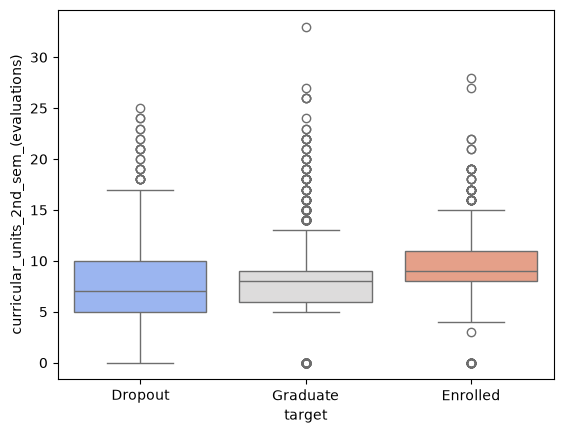

In [99]:
sns.boxplot(data=students, x='target', y='curricular_units_2nd_sem_(evaluations)', palette="coolwarm", hue='target', legend=False);

In [100]:
Q3_d_2 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(evaluations)'].quantile(0.75)
Q1_d_2 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(evaluations)'].quantile(0.25)
IQR_d_2 = Q3_d_2 - Q1_d_2

Q3_e_2 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(evaluations)'].quantile(0.75)
Q1_e_2 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(evaluations)'].quantile(0.25)
IQR_e_2 = Q3_e_2 - Q1_e_2

Q3_g_2 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(evaluations)'].quantile(0.75)
Q1_g_2 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(evaluations)'].quantile(0.25)
IQR_g_2 = Q3_g_2 - Q1_g_2

print(IQR_d_2)
print(IQR_e_2)
print(IQR_g_2)

5.0
3.0
3.0


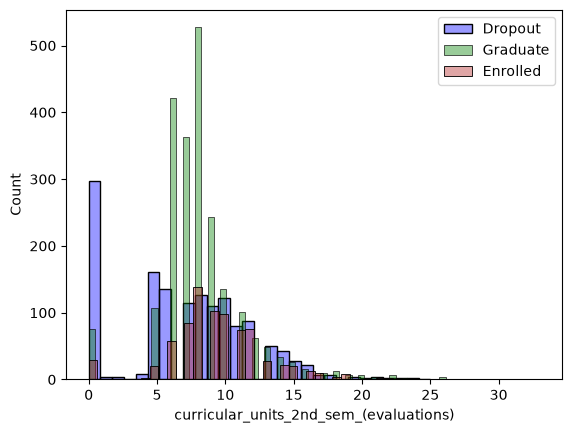

In [101]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='curricular_units_2nd_sem_(evaluations)', color="blue", alpha=0.4, label = "Dropout", ax=axes);
sns.histplot(data=students[students['target'] == "Graduate"], x='curricular_units_2nd_sem_(evaluations)', color="green", alpha=0.4, ax=axes, label = "Graduate", legend=True);
sns.histplot(data=students[students['target'] == "Enrolled"], x='curricular_units_2nd_sem_(evaluations)', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled", legend=True);
axes.legend()
plt.show()

### ANOVA test
- H0 - our groups are equal
- H1 - our groups not equal

In [102]:
dropout_df_2 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(evaluations)']
graduate_df_2 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(evaluations)']
enrolled_df_2 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(evaluations)']

In [103]:
st.f_oneway(dropout_df_2, graduate_df_2, enrolled_df_2)

F_onewayResult(statistic=np.float64(87.80109205125237), pvalue=np.float64(4.039136880374516e-38))

## 7. Column "curricular_units_2nd_sem_(approved)"

In [104]:
students.groupby('target')['curricular_units_2nd_sem_(approved)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,1.940183,0.0,2.573691,0,16,1421
Enrolled,4.057935,4.0,2.180197,0,12,794
Graduate,6.177003,6.0,2.268622,0,20,2209


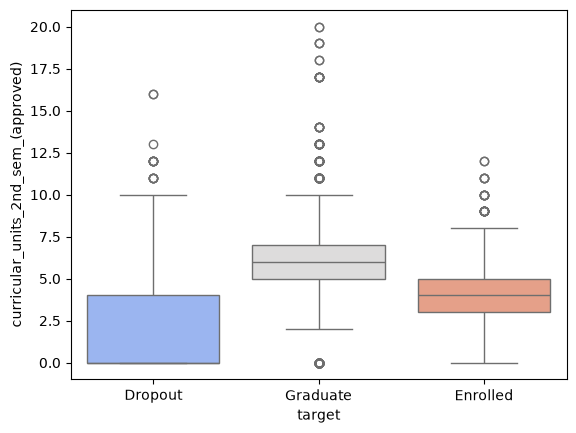

In [105]:
sns.boxplot(data=students, x='target', y='curricular_units_2nd_sem_(approved)', palette="coolwarm", hue='target', legend=False);

In [106]:
Q3_d_3 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(approved)'].quantile(0.75)
Q1_d_3 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(approved)'].quantile(0.25)
IQR_d_3 = Q3_d_3 - Q1_d_3

Q3_e_3 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(approved)'].quantile(0.75)
Q1_e_3 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(approved)'].quantile(0.25)
IQR_e_3 = Q3_e_3 - Q1_e_3

Q3_g_3 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(approved)'].quantile(0.75)
Q1_g_3 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(approved)'].quantile(0.25)
IQR_g_3 = Q3_g_3 - Q1_g_3

print(IQR_d_3)
print(IQR_e_3)
print(IQR_g_3)

4.0
2.0
2.0


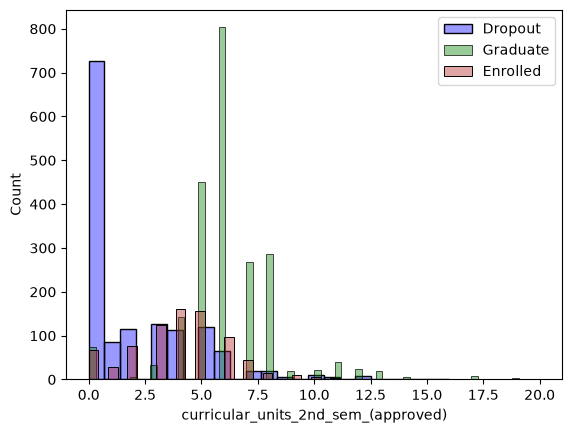

In [107]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='curricular_units_2nd_sem_(approved)', color="blue", alpha=0.4, label = "Dropout", ax=axes);
sns.histplot(data=students[students['target'] == "Graduate"], x='curricular_units_2nd_sem_(approved)', color="green", alpha=0.4, ax=axes, label = "Graduate", legend=True);
sns.histplot(data=students[students['target'] == "Enrolled"], x='curricular_units_2nd_sem_(approved)', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled", legend=True);
axes.legend()
plt.show()

### ANOVA test

H0 - our groups are equal
H1 - our groups not equal

In [108]:
dropout_df_3 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(approved)']
graduate_df_3 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(approved)']
enrolled_df_3 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(approved)']

In [109]:
st.f_oneway(dropout_df_3, graduate_df_3, enrolled_df_3)

F_onewayResult(statistic=np.float64(1410.732938379365), pvalue=np.float64(0.0))

## 8. Column "curricular_units_2nd_sem_(grade)"

In [110]:
students.groupby('target')['curricular_units_2nd_sem_(grade)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,5.899339,0.0,6.118740,0.0,17.714286,1421
Enrolled,11.117364,12.0,3.601240,0.0,17.600000,794
Graduate,12.697276,13.0,2.685608,0.0,18.571429,2209


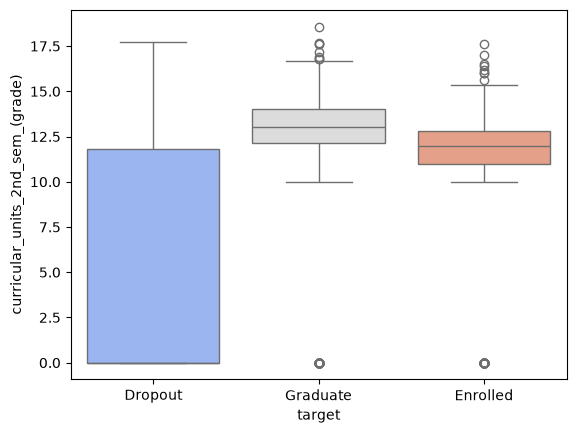

In [111]:
sns.boxplot(data=students, x='target', y='curricular_units_2nd_sem_(grade)', palette="coolwarm", hue='target', legend=False);

In [112]:
Q3_d_4 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(grade)'].quantile(0.75)
Q1_d_4 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(grade)'].quantile(0.25)
IQR_d_4 = Q3_d_4 - Q1_d_4

Q3_e_4 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(grade)'].quantile(0.75)
Q1_e_4 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(grade)'].quantile(0.25)
IQR_e_4 = Q3_e_4 - Q1_e_4

Q3_g_4 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(grade)'].quantile(0.75)
Q1_g_4 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(grade)'].quantile(0.25)
IQR_g_4 = Q3_g_4 - Q1_g_4

print(IQR_d_4)
print(IQR_e_4)
print(IQR_g_4)

11.833333333333334
1.8181818181818183
1.833333333333334


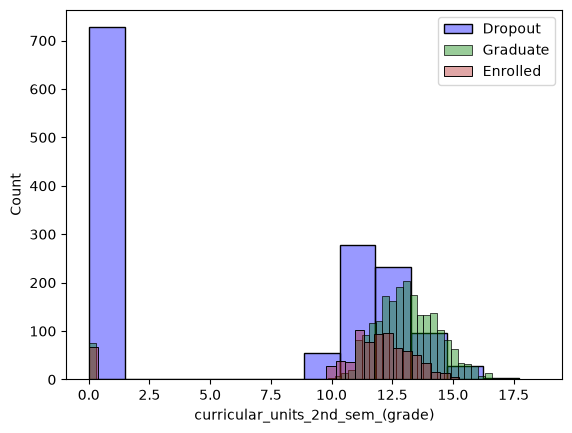

In [113]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='curricular_units_2nd_sem_(grade)', color="blue", alpha=0.4, label = "Dropout", ax=axes);
sns.histplot(data=students[students['target'] == "Graduate"], x='curricular_units_2nd_sem_(grade)', color="green", alpha=0.4, ax=axes, label = "Graduate", legend=True);
sns.histplot(data=students[students['target'] == "Enrolled"], x='curricular_units_2nd_sem_(grade)', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled", legend=True);
axes.legend()
plt.show()

### ANOVA test

H0 - our groups are equal
H1 - our groups not equal

In [114]:
dropout_df_4 = students[students["target"] == "Dropout"]['curricular_units_2nd_sem_(grade)']
graduate_df_4 = students[students["target"] == "Graduate"]['curricular_units_2nd_sem_(grade)']
enrolled_df_4 = students[students["target"] == "Enrolled"]['curricular_units_2nd_sem_(grade)']

In [115]:
st.f_oneway(dropout_df_4, graduate_df_4, enrolled_df_4)

F_onewayResult(statistic=np.float64(1134.1095443408376), pvalue=np.float64(0.0))

## 9. Column "curricular_units_2nd_sem_(without_evaluations)"

In [116]:
students.groupby('target')['curricular_units_2nd_sem_(without_evaluations)'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,0.237861,0.0,0.994210,0,12,1421
Enrolled,0.187657,0.0,0.780467,0,8,794
Graduate,0.080579,0.0,0.522872,0,12,2209


## 10. Column "unemployment_rate"

In [117]:
students.groupby('target')['unemployment_rate'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])

,mean,median,std,min,max,count
target,,,,,,
Dropout,11.616397,11.1,2.768259,7.6,16.2,1421
Enrolled,11.272544,11.1,2.628139,7.6,16.2,794
Graduate,11.639339,11.1,2.601474,7.6,16.2,2209


## 11. Column "inflation_rate"

In [118]:
students.groupby('target')['inflation_rate'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])


,mean,median,std,min,max,count
target,,,,,,
Dropout,1.283955,1.4,1.404970,-0.8,3.7,1421
Enrolled,1.211713,1.4,1.373355,-0.8,3.7,794
Graduate,1.197918,0.6,1.371116,-0.8,3.7,2209


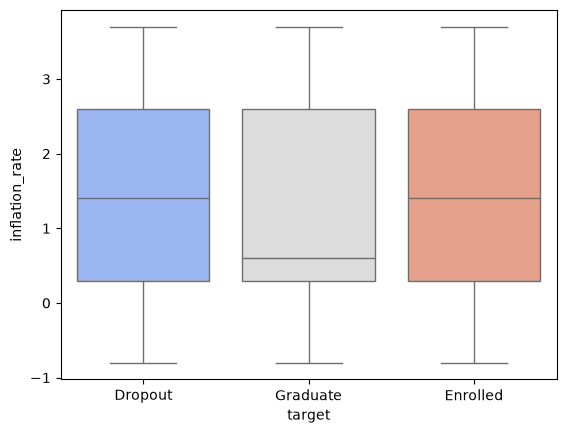

In [119]:
sns.boxplot(data=students, x='target', y='inflation_rate', palette="coolwarm", hue='target', legend=False);

In [120]:
Q3_d_ir = students[students["target"] == "Dropout"]['inflation_rate'].quantile(0.75)
Q1_d_ir = students[students["target"] == "Dropout"]['inflation_rate'].quantile(0.25)
IQR_d_ir = Q3_d_ir - Q1_d_ir

Q3_e_ir = students[students["target"] == "Enrolled"]['inflation_rate'].quantile(0.75)
Q1_e_ir = students[students["target"] == "Enrolled"]['inflation_rate'].quantile(0.25)
IQR_e_ir = Q3_e_ir - Q1_e_ir

Q3_g_ir = students[students["target"] == "Graduate"]['inflation_rate'].quantile(0.75)
Q1_g_ir = students[students["target"] == "Graduate"]['inflation_rate'].quantile(0.25)
IQR_g_ir = Q3_g_ir - Q1_g_ir

print(IQR_d_ir)
print(IQR_e_ir)
print(IQR_g_ir)

2.3000000000000003
2.3000000000000003
2.3000000000000003


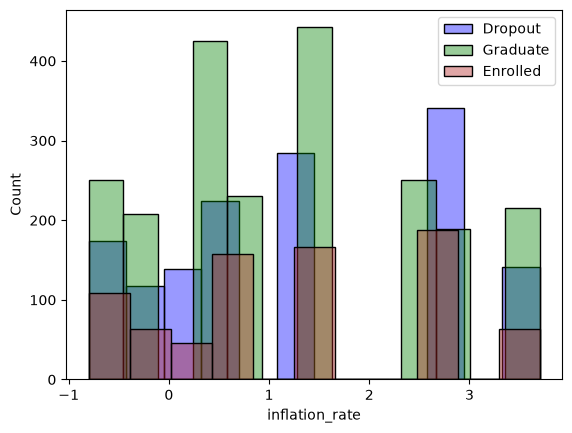

In [121]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='inflation_rate', color="blue", alpha=0.4, ax=axes, label = "Dropout");
sns.histplot(data=students[students['target'] == "Graduate"], x='inflation_rate', color="green", alpha=0.4, ax=axes, label = "Graduate");
sns.histplot(data=students[students['target'] == "Enrolled"], x='inflation_rate', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled");
axes.legend()
plt.show()

### ANOVA test

H0 - our groups are equal
H1 - our groups not equal

In [122]:
dropout_df_3 = students[students["target"] == "Dropout"]['inflation_rate']
graduate_df_3 = students[students["target"] == "Graduate"]['inflation_rate']
enrolled_df_3 = students[students["target"] == "Enrolled"]['inflation_rate']

In [123]:
st.f_oneway(dropout_df_3, graduate_df_3, enrolled_df_3)

F_onewayResult(statistic=np.float64(1.7419897938269673), pvalue=np.float64(0.1752917124393327))

## 12. Column "gdp"

In [124]:
grouped_df_5 = students.groupby('target')['gdp'].agg(['mean', 'median', 'std', 'min', 'max', 'count'])
grouped_df_5

,mean,median,std,min,max,count
target,,,,,,
Dropout,-0.150859,0.32,2.251768,-4.06,3.51,1421
Enrolled,0.053287,0.32,2.315631,-4.06,3.51,794
Graduate,0.081833,0.79,2.261081,-4.06,3.51,2209


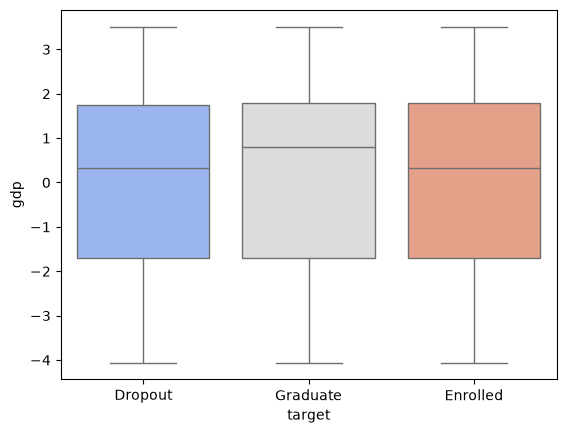

In [125]:
sns.boxplot(data=students, x='target', y='gdp', palette="coolwarm", hue='target', legend=False);

In [126]:
Q3_d_gdp = students[students["target"] == "Dropout"]['gdp'].quantile(0.75)
Q1_d_gdp = students[students["target"] == "Dropout"]['gdp'].quantile(0.25)
IQR_d_gdp = Q3_d_gdp - Q1_d_gdp

Q3_e_gdp = students[students["target"] == "Enrolled"]['gdp'].quantile(0.75)
Q1_e_gdp = students[students["target"] == "Enrolled"]['gdp'].quantile(0.25)
IQR_e_gdp = Q3_e_gdp - Q1_e_gdp

Q3_g_gdp = students[students["target"] == "Graduate"]['gdp'].quantile(0.75)
Q1_g_gdp = students[students["target"] == "Graduate"]['gdp'].quantile(0.25)
IQR_g_gdp = Q3_g_gdp - Q1_g_gdp

print(IQR_d_gdp)
print(IQR_e_gdp)
print(IQR_g_gdp)

3.44
3.49
3.49


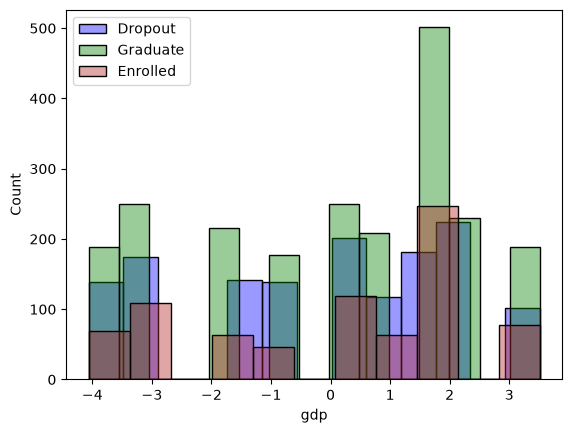

In [127]:
fig, axes = plt.subplots()
sns.histplot(data=students[students['target'] == "Dropout"], x='gdp', color="blue", alpha=0.4, ax=axes, label = "Dropout");
sns.histplot(data=students[students['target'] == "Graduate"], x='gdp', color="green", alpha=0.4, ax=axes, label = "Graduate");
sns.histplot(data=students[students['target'] == "Enrolled"], x='gdp', color="firebrick", alpha=0.4, ax=axes, label = "Enrolled");
axes.legend()
plt.show()

### ANOVA test

H0 - our groups are equal
H1 - our groups not equal

In [128]:
dropout_df = students[students["target"] == "Dropout"]['gdp']
graduate_df = students[students["target"] == "Graduate"]['gdp']
enrolled_df = students[students["target"] == "Enrolled"]['gdp']

In [129]:
st.f_oneway(dropout_df, graduate_df, enrolled_df)

F_onewayResult(statistic=np.float64(4.799008995763781), pvalue=np.float64(0.008280870491684128))

**Main conclusion**

Based on statistical analysis, we select the two most significant features: 
 - "curricular_units_1st_sem_(approved)"
 - "curricular_units_1st_sem_(grade)"

For both of them, we observe different median values for each student group ("Dropout", "Graduate", "Enrolled"), which may indicate an uneven distribution across the categories of interest. An additional ANOVA tests confirms the suggestion that the selected features demonstrate an uneven distribution of students into subgroups. This means that the results in these columns provide the necessary data for subgroup distribution.  

Also features "curricular_units_2st_sem_(approved)" and "curricular_units_2st_sem_(grade)" could possibly be included into further investigation, but the goal of this project is to identify students who are at risk of being expelled as early as possible, so it makes no sense to consider the data from the second semester